In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # Initial guess
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)     
        if abs(g_prime_val) < tol:  # Avoid division by zero
            break
        y_new = y_next - g_val / g_prime_val
        if abs(y_new - y_next) < tol:
            return y_new  # Converged
        y_next = y_new
    return y_next

# Adaptive Backward Euler
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    h = h_init
    t = t0
    y = y0
    while t < tf:
        if t + h > tf:  # Adjust step size to not overshoot
            h = tf - t
        # Single step with h
        y_full = backward_euler_step(f, y, t, h, tol, max_iter)
        # Two half-steps with h/2
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)
        # Error estimation
        error = abs(y_full - y_half_2)
        # Adjust step size
        if error > tol:
            h /= 2  # Decrease step size
            continue  # Retry the step with smaller h
        elif error < tol / 2:
            h *= 2  # Increase step size for efficiency
        # Accept the step
        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)

In [9]:
def f(t, y):
    return y**2 - 10

def fprime(y):
    return 2*y

t values:
[0.0000000e+00 3.9062500e-04 7.8125000e-04 ... 3.7578125e+00 4.5578125e+00
 5.4421875e+00]

y values:
[ 1.          0.99648232  0.9929619  ... -3.1622758  -3.1622773
 -3.1622776 ]


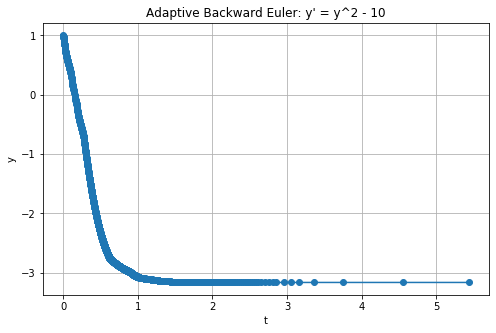

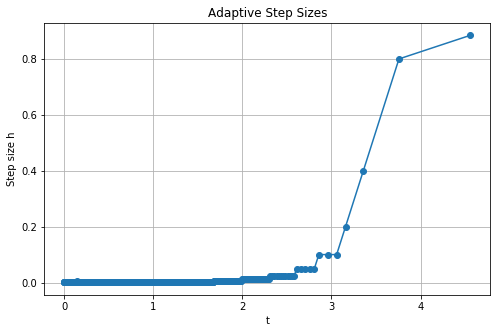

In [10]:
# Run solver
t_vals, y_vals = backward_euler_adaptive(f, y0=1, t0=0, tf=5, h_init=0.1)

# Print values
print("t values:")
print(t_vals)

print("\ny values:")
print(y_vals)

# Plot solution
plt.figure(figsize=(8,5))
plt.plot(t_vals, y_vals, marker='o')
plt.xlabel("t")
plt.ylabel("y")
plt.title("Adaptive Backward Euler: y' = y^2 - 10")
plt.grid(True)
plt.show()

# Plot step sizes used
step_sizes = np.diff(t_vals)

plt.figure(figsize=(8,5))
plt.plot(t_vals[:-1], step_sizes, marker='o')
plt.xlabel("t")
plt.ylabel("Step size h")
plt.title("Adaptive Step Sizes")
plt.grid(True)
plt.show()